**Imports necessários e funções básicas.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2
import os

def plotar_imagem(img, img_modificada, tituloum, titulodois):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    if img.ndim == 3:
        im1 = ax[0].imshow(img)
        ax[0].set_title(tituloum)

        im2 = ax[1].imshow(img_modificada)
        ax[1].set_title(titulodois)
    else:
        im1 = ax[0].imshow(img, cmap='gray')
        ax[0].set_title(tituloum)

        im2 = ax[1].imshow(img_modificada, cmap='gray')
        ax[1].set_title(titulodois)

    plt.show()

def salvar_imagem(img, nome):
    
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
        
    if len(img.shape) == 3:
        img_para_salvar = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    else:
        img_para_salvar = img
        
    nome_projeto, extensao = os.path.splitext(nome)
    if not extensao:
        nome = nome + ".png"
        print(f"Nenhuma extensão detectada. Salvando automaticamente como '{nome}'")
        
    sucesso = cv2.imwrite(nome, img_para_salvar)
    
    if sucesso:
        print(f"Imagem salva com sucesso como: '{nome}'")
    else:
        print(f"Erro ao tentar salvar a imagem '{nome}'. Verifique o caminho.")
    

# **Métodos de Interpolação**

**Transformações geométricas**

In [7]:
def escala(img, fator_escala):
    altura, largura = img.shape[:2]
    
    altura_nova = int(altura * fator_escala)
    largura_nova = int(largura * fator_escala)
    
    Y, X = np.indices((altura_nova,largura_nova))
    
    # Matriz de 3 linhas para multiplicação com S_inv
    coords = np.stack([
        X.ravel(),
        Y.ravel(),
        np.ones(altura_nova * largura_nova)
    ])
    
    S_inv = np.array([
        [1/fator_escala, 0, 0],
        [0, 1/fator_escala, 0],
        [0, 0, 1]
    ])
    
    # De fato convertendo
    coords_novas = np.dot(S_inv, coords)
    
    # Remontando no formato matricial
    X_m = coords_novas[0, :].reshape(altura_nova, largura_nova)
    Y_m = coords_novas[1, :].reshape(altura_nova, largura_nova)
    
    return X_m, Y_m


# Aqui a rotação é considerando o centro da imagem, então é feito
# uma rotação para a origem, uma rotação, e depois voltamos ao normal
def rotacao(img, angulo):
    altura, largura = img.shape[:2]
    
    altura_nova = altura
    largura_nova = largura
    
    Y, X = np.indices((altura_nova,largura_nova))
    
    # Matriz de 3 linhas para multiplicação com S_inv
    coords = np.stack([
        X.ravel(),
        Y.ravel(),
        np.ones(altura_nova * largura_nova)
    ])
    
    centro_x = largura/2.0
    centro_y = largura/2.0
    
    rad = np.radians(angulo)
    cos_t = np.cos(rad)
    sen_t = np.sin(rad)

    T = np.array([
        [1, 0, -centro_x],
        [0, 1, -centro_y],
        [0, 0, 1]
    ])

    R_inv = np.array([
        [cos_t, sen_t, 0],
        [-sen_t, cos_t, 0],
        [0, 0, 1]
    ])
    
    T_inv = np.array([
        [1, 0, centro_x],
        [0, 1, centro_y],
        [0, 0, 1]
    ])
    
    # De fato convertendo
    matriz_intermediaria = np.dot(T_inv, R_inv)
    M_inv = np.dot(matriz_intermediaria, T)
    coords_novas = np.dot(M_inv, coords)
    
    # Remontando no formato matricial
    X_m = coords_novas[0, :].reshape(altura_nova, largura_nova)
    Y_m = coords_novas[1, :].reshape(altura_nova, largura_nova)
    
    return X_m, Y_m

def redimensionamento(img, altura_nova, largura_nova):
    altura, largura = img.shape[:2]
    
    fator_x = largura_nova / largura
    fator_y = altura_nova / altura
    
    Y, X = np.indices((altura_nova,largura_nova))
    
    # Matriz de 3 linhas para multiplicação com S_inv
    coords = np.stack([
        X.ravel(),
        Y.ravel(),
        np.ones(altura_nova * largura_nova)
    ])
    
    S_inv = np.array([
        [1/fator_x, 0, 0],
        [0, 1/fator_y, 0],
        [0, 0, 1]
    ])
    
    # De fato convertendo
    coords_novas = np.dot(S_inv, coords)
    
    # Remontando no formato matricial
    X_m = coords_novas[0, :].reshape(altura_nova, largura_nova)
    Y_m = coords_novas[1, :].reshape(altura_nova, largura_nova)
    
    return X_m, Y_m


**Métodos de Interpolação**

In [64]:
import numpy as np

def vizinho_mais_proximo(img, X_m, Y_m):
    altura, largura = img.shape[:2]
    
    X_proximo = np.round(X_m).astype(int)
    Y_proximo = np.round(Y_m).astype(int)
    
    X_clip = np.clip(X_proximo, 0, largura - 1)
    Y_clip = np.clip(Y_proximo, 0, altura - 1)
    
    img_nova = img[Y_clip, X_clip].copy()
    
    valido_x = (X_m >= 0) & (X_m < largura)
    valido_y = (Y_m >= 0) & (Y_m < altura)
    mascara_invalido = ~(valido_x & valido_y)
    
    # Ajuste genérico para máscaras em imagens RGB
    if len(img.shape) == 3:
        mascara_invalido = mascara_invalido[:, :, np.newaxis]
    
    img_nova = np.where(mascara_invalido, 0, img_nova)
    
    return img_nova.astype(np.uint8)

def bilinear(img, X_m, Y_m):
    altura, largura = img.shape[:2]
    
    X_f = np.floor(X_m).astype(int)
    Y_f = np.floor(Y_m).astype(int)
    
    dx = X_m - X_f
    dy = Y_m - Y_f
    
    dx = dx[:, :, np.newaxis] if len(img.shape) == 3 else dx
    dy = dy[:, :, np.newaxis] if len(img.shape) == 3 else dy
    
    X0 = np.clip(X_f, 0, largura - 1)
    X1 = np.clip(X_f + 1, 0, largura - 1)
    Y0 = np.clip(Y_f, 0, altura - 1)
    Y1 = np.clip(Y_f + 1, 0, altura - 1)
    
    Ia = img[Y0, X0] 
    Ib = img[Y1, X0] 
    Ic = img[Y0, X1] 
    Id = img[Y1, X1] 
    
    img_nova = Ia * (1 - dx) * (1 - dy)
    img_nova += Ib * (1 - dx) * dy
    img_nova += Ic * dx * (1 - dy)
    img_nova += Id * dx * dy
        
    valido_x = (X_m >= 0) & (X_m < largura)
    valido_y = (Y_m >= 0) & (Y_m < altura)
    mascara_invalido = ~(valido_x & valido_y)
    
    # Ajuste genérico para máscaras em imagens RGB
    if len(img.shape) == 3:
        mascara_invalido = mascara_invalido[:, :, np.newaxis]
    
    img_nova = np.where(mascara_invalido, 0, img_nova)
    
    return img_nova.astype(np.uint8)

def R(s):
    p_s2 = np.maximum(0, s + 2) ** 3
    p_s1 = np.maximum(0, s + 1) ** 3
    p_s0 = np.maximum(0, s) ** 3
    p_sm1 = np.maximum(0, s - 1) ** 3
    return (1.0 / 6.0) * (p_s2 - 4 * p_s1 + 6 * p_s0 - 4 * p_sm1)

def bicubica(img, X_m, Y_m):
    altura, largura = img.shape[:2]
    
    X_f = np.floor(X_m).astype(int)
    Y_f = np.floor(Y_m).astype(int)
    
    dx = X_m - X_f
    dy = Y_m - Y_f
    
    if len(img.shape) == 3: 
        img_nova = np.zeros((X_m.shape[0], X_m.shape[1], img.shape[2]), dtype=np.float64)
    else: 
        img_nova = np.zeros((X_m.shape[0], X_m.shape[1]), dtype=np.float64)
        
    for m in range(-1, 3):
        for n in range(-1, 3):
            X_vizinho = np.clip(X_f + m, 0, largura - 1)
            Y_vizinho = np.clip(Y_f + n, 0, altura - 1)
            
            f_vizinho = img[Y_vizinho, X_vizinho]
            
            peso_x = R(m - dx)
            peso_y = R(dy - n)
            
            if len(img.shape) == 3:
                peso_x = peso_x[:, :, np.newaxis]
                peso_y = peso_y[:, :, np.newaxis]
                
            img_nova += f_vizinho * peso_x * peso_y

    valido_x = (X_m >= 0) & (X_m < largura)
    valido_y = (Y_m >= 0) & (Y_m < altura)
    mascara_invalido = ~(valido_x & valido_y)
    
    # Ajuste genérico para máscaras em imagens RGB
    if len(img.shape) == 3:
        mascara_invalido = mascara_invalido[:, :, np.newaxis]
    
    img_nova = np.where(mascara_invalido, 0, img_nova)
    
    img_nova = np.clip(img_nova, 0, 255)
    return img_nova.astype(np.uint8)

def L(n, dx, img, X_f, Y_f, largura, altura):
    X_m1 = np.clip(X_f - 1, 0, largura - 1)
    X_0  = np.clip(X_f,     0, largura - 1)
    X_1  = np.clip(X_f + 1, 0, largura - 1)
    X_2  = np.clip(X_f + 2, 0, largura - 1)
    
    Y_viz = np.clip(Y_f + n - 2, 0, altura - 1)
    
    f_m1 = img[Y_viz, X_m1]
    f_0  = img[Y_viz, X_0]
    f_1  = img[Y_viz, X_1]
    f_2  = img[Y_viz, X_2]
    
    dx_b = dx[:, :, np.newaxis] if len(img.shape) == 3 else dx
        
    termo1 = ( -dx_b * (dx_b - 1) * (dx_b - 2) * f_m1 ) / 6.0
    termo2 = ( (dx_b + 1) * (dx_b - 1) * (dx_b - 2) * f_0 ) / 2.0
    termo3 = ( -dx_b * (dx_b + 1) * (dx_b - 2) * f_1 ) / 2.0
    termo4 = ( dx_b * (dx_b + 1) * (dx_b - 1) * f_2 ) / 6.0
    
    return termo1 + termo2 + termo3 + termo4

def lagrange(img, X_m, Y_m):
    altura, largura = img.shape[:2]
    
    X_f = np.floor(X_m).astype(int)
    Y_f = np.floor(Y_m).astype(int)
    
    dx = X_m - X_f
    dy = Y_m - Y_f
    
    L1 = L(1, dx, img, X_f, Y_f, largura, altura)
    L2 = L(2, dx, img, X_f, Y_f, largura, altura)
    L3 = L(3, dx, img, X_f, Y_f, largura, altura)
    L4 = L(4, dx, img, X_f, Y_f, largura, altura)
    
    dy_b = dy[:, :, np.newaxis] if len(img.shape) == 3 else dy
        
    img_nova = ( -dy_b * (dy_b - 1) * (dy_b - 2) * L1 ) / 6.0
    img_nova += ( (dy_b + 1) * (dy_b - 1) * (dy_b - 2) * L2 ) / 2.0
    img_nova += ( -dy_b * (dy_b + 1) * (dy_b - 2) * L3 ) / 2.0
    img_nova += ( dy_b * (dy_b + 1) * (dy_b - 1) * L4 ) / 6.0
    
    valido_x = (X_m >= 0) & (X_m < largura)
    valido_y = (Y_m >= 0) & (Y_m < altura)
    mascara_invalido = ~(valido_x & valido_y)
    
    # Ajuste genérico para máscaras em imagens RGB
    if len(img.shape) == 3:
        mascara_invalido = mascara_invalido[:, :, np.newaxis]
    
    img_nova = np.where(mascara_invalido, 0, img_nova)
    
    img_nova = np.clip(img_nova, 0, 255)
    return img_nova.astype(np.uint8)

**Execução**

Nenhuma extensão detectada. Salvando automaticamente como 'olhospilagrange.png'
Imagem salva com sucesso como: 'olhospilagrange.png'


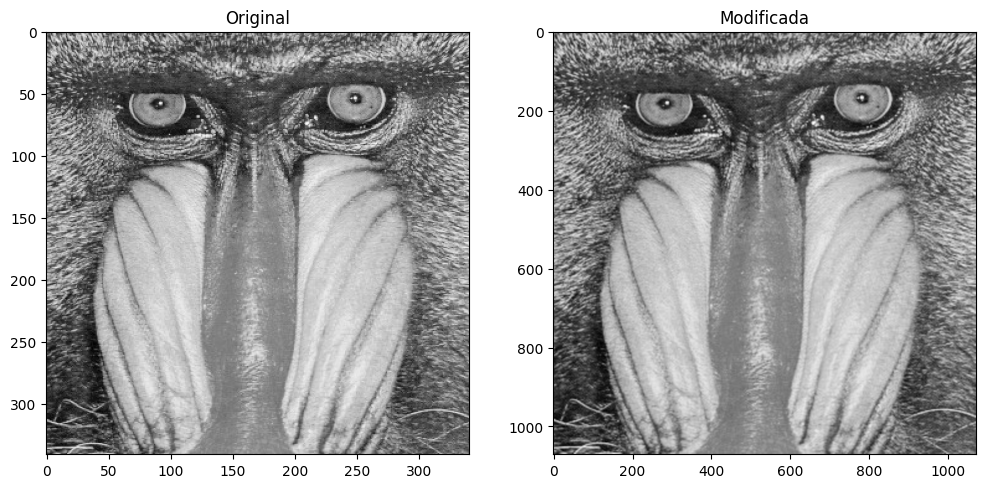

In [ ]:
# Escolha de imagem
caminho = input("Caminho para a imagem(ex.: watch.png): ")
img = cv2.imread(caminho, cv2.IMREAD_UNCHANGED)

if img is None:
    raise FileNotFoundError(f"Não foi possível carregar a imagem no caminho: '{caminho}'")
if img.ndim == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Escolha de transformação
transformacao = int(input("| 1 - Rotação no centro da imagem\n| 2 - Fator de Escala\n| 3 - Redimensionamento"))
if transformacao == 1:
    angulo = float(input("Ângulo em graus: "))
    X_m, Y_m = rotacao(img, angulo)
elif transformacao == 2:
    fator_escala = float(input("Fator de escala: "))
    X_m, Y_m = escala(img, fator_escala)
elif transformacao == 3:
    r_x, r_y = map(int,input("Largura e Altura separadas por espaço(Valores inteiros): ").split())
    X_m, Y_m = redimensionamento(img, r_y, r_x)
else:
    raise ValueError(f"Opção {transformacao} é uma transformação inválida!")

# Escolha de método
metodo = int(input("| 1 - Interpolação pelo Vizinho mais Próximo\n| 2 - Interpolação Bilinear\n| 3 - Interpolação Bicúbica\n| 4 - Interpolação por Polinômio de Lagrange"))
if metodo == 1:
    img_nova = vizinho_mais_proximo(img, X_m, Y_m)
elif metodo == 2:
    img_nova = bilinear(img, X_m, Y_m)
elif metodo == 3:
    img_nova = bicubica(img, X_m, Y_m)
elif metodo == 4:
    img_nova = lagrange(img, X_m, Y_m)
else:
    raise ValueError(f"Opção {metodo} é um método de interpolação inválido!")

nome_saida = input("Nome para imagem de saída(ex.:teste.png): ")
salvar_imagem(img_nova, nome_saida)

plotar_imagem(img, img_nova, "Original", "Modificada")


**Diferença entre Bicúbica e Polinômios de Lagrange**

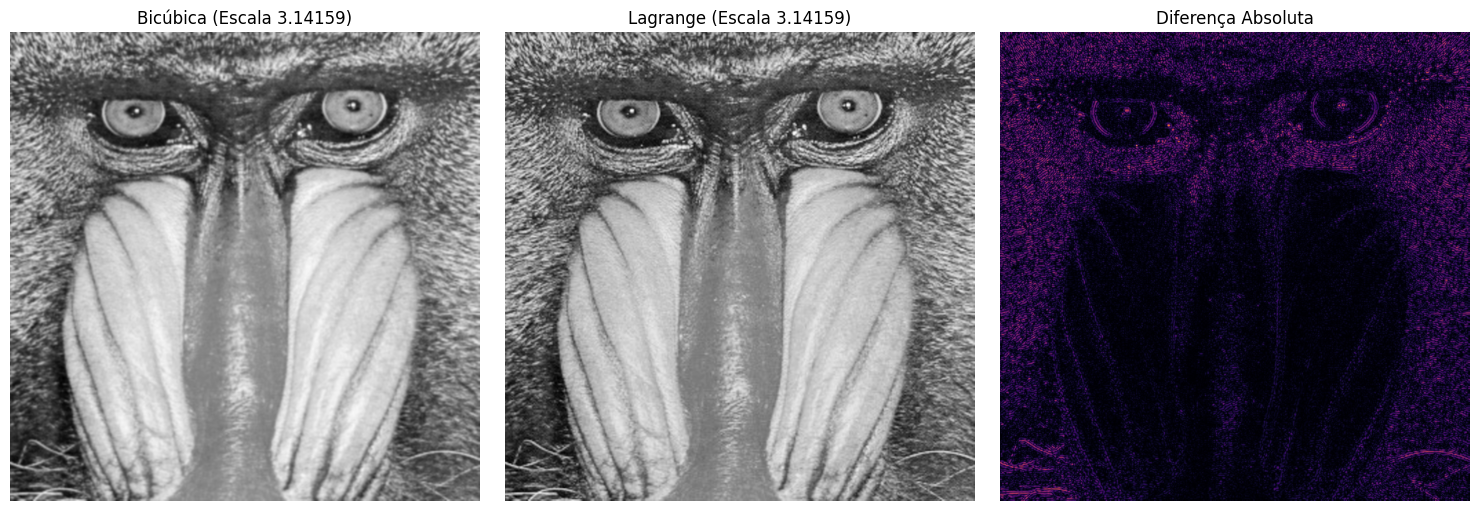

In [68]:
def calcular_e_plotar_diferenca(caminho_imagem, fator_escala=3.14159):
    img = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Não foi possível carregar a imagem no caminho: '{caminho_imagem}'")
        
    X_m, Y_m = escala(img, fator_escala)
    
    img_bicubica = bicubica(img, X_m, Y_m)
    
    img_lagrange = lagrange(img, X_m, Y_m)
    
    diferenca_real = np.abs(img_bicubica.astype(np.float64) - img_lagrange.astype(np.float64))
    
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_bicubica, cmap='gray')
    plt.title(f"Bicúbica (Escala {fator_escala:.5f})")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_lagrange, cmap='gray')
    plt.title(f"Lagrange (Escala {fator_escala:.5f})")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(diferenca_real, cmap='inferno')
    plt.title("Diferença Absoluta")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

calcular_e_plotar_diferenca("olhos.png", fator_escala=3.14159)

**Comparação de tempo**


In [54]:
import time


def benchmark_interpolacoes(caminho_imagem, num_tentativas=5, fator_escala=3.14159):
    img = cv2.imread(caminho_imagem, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Não foi possível carregar a imagem: {caminho_imagem}")
        
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
    X_m, Y_m = escala(img, fator_escala)
    
    # Dicionário com as funções que você já tem implementadas no seu código
    metodos = {
        "Vizinho Mais Próximo": vizinho_mais_proximo,
        "Bilinear": bilinear,
        "Bicúbica": bicubica,
        "Lagrange": lagrange
    }
    
    lista_medias = []
    
    print(f"Iniciando Benchmark ({num_tentativas} execuções por método com escala {fator_escala})...\n")
    print(f"{'Método':<25} | {'Tempo Médio (segundos)':<25}")
    print("-" * 55)
    
    for nome, funcao_metodo in metodos.items():
        tempos = []
        
        for _ in range(num_tentativas):
            t_inicio = time.perf_counter() # Medição de alta precisão
            _ = funcao_metodo(img, X_m, Y_m)
            t_fim = time.perf_counter()
            
            tempos.append(t_fim - t_inicio)
            
        tempo_medio = np.mean(tempos)
        lista_medias.append((nome, tempo_medio))
        
        print(f"{nome:<25} | {tempo_medio:<25.6f}")
        
    return lista_medias

resultados = benchmark_interpolacoes("olhos.png", num_tentativas=5, fator_escala=3.14159)

Iniciando Benchmark (5 execuções por método com escala 3.14159)...

Método                    | Tempo Médio (segundos)   
-------------------------------------------------------
Vizinho Mais Próximo      | 0.146033                 
Bilinear                  | 0.407047                 
Bicúbica                  | 14.379146                
Lagrange                  | 1.914669                 
